In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train: {len(train_dataset)}  Test: {len(test_dataset)}')


class SPARNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(196, 64, bias=True)
        self.fc2 = nn.Linear(64, 64, bias=True)

        # One 4x4 transform per slice ("W3" in the hardware memory map)
        self.W2 = nn.Parameter(torch.randn(16, 4, 4) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(16, 4, 4))

        # Learned reduction weights
        self.reducer = nn.Parameter(torch.randn(16, 4, 4) * 0.1)

        self.relu = nn.ReLU()

    def forward(self, x):
        B = x.shape[0]
        x = x.flatten(start_dim=1)
        x = x.reshape(B, 4, 196)

        x = self.relu(self.fc1(x))      # [B,4,64]
        x = self.relu(self.fc2(x))      # [B,4,64]

        x = x.reshape(B, 4, 16, 4)
        x = x.permute(0, 2, 1, 3)       # [B,16,4,4]

        S = x.reshape(B * 16, 4, 4)
        W2 = self.W2.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
        b2 = self.b2.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)

        R = torch.bmm(S, W2) + b2
        R = self.relu(R)
        R = R.reshape(B, 16, 4, 4)

        scores = (R * self.reducer.unsqueeze(0)).sum(dim=(2, 3))
        scores = scores[:, :10]
        return scores


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; correct = 0; total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += out.argmax(1).eq(target).sum().item()
        total += target.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            total_loss += criterion(out, target).item()
            correct += out.argmax(1).eq(target).sum().item()
            total += target.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def train_model(model, name, epochs=15, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0
    print(f'\n{"="*55}\n  Training {name}\n{"="*55}')
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), f'{name}_best.pt')
        print(f'Epoch {epoch:2d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.2f}% | '
              f'val loss {va_loss:.4f} acc {va_acc:.2f}%')
    elapsed = time.time() - start_time
    print(f'\nBest val acc : {best_acc:.2f}%\nTime         : {elapsed:.1f}s')
    return history, best_acc


model = SPARNet().to(device)
params = sum(p.numel() for p in model.parameters())
print(f'\nSPARNet parameter count: {params:,}')

history, best_acc = train_model(model, 'SPARNet', epochs=15)
print(f'\nFinal best accuracy: {best_acc:.2f}%')

Using device: cpu
Train: 60000  Test: 10000

SPARNet parameter count: 17,536

  Training SPARNet
Epoch  1/15 | train loss 0.5602 acc 84.20% | val loss 0.2480 acc 92.87%
Epoch  2/15 | train loss 0.2203 acc 93.58% | val loss 0.1713 acc 94.98%
Epoch  3/15 | train loss 0.1649 acc 95.17% | val loss 0.1436 acc 95.78%
Epoch  4/15 | train loss 0.1361 acc 96.01% | val loss 0.1220 acc 96.26%
Epoch  5/15 | train loss 0.1183 acc 96.54% | val loss 0.1118 acc 96.57%
Epoch  6/15 | train loss 0.0982 acc 97.16% | val loss 0.1052 acc 96.67%
Epoch  7/15 | train loss 0.0926 acc 97.30% | val loss 0.1103 acc 96.71%
Epoch  8/15 | train loss 0.0873 acc 97.45% | val loss 0.1024 acc 96.82%
Epoch  9/15 | train loss 0.0825 acc 97.60% | val loss 0.0974 acc 96.94%
Epoch 10/15 | train loss 0.0785 acc 97.64% | val loss 0.0962 acc 97.01%
Epoch 11/15 | train loss 0.0703 acc 97.93% | val loss 0.0916 acc 97.00%
Epoch 12/15 | train loss 0.0684 acc 97.97% | val loss 0.0937 acc 97.06%
Epoch 13/15 | train loss 0.0665 acc 98.

## Rewritten quantization pipeline

**What was wrong before:** every tensor was quantized with `scale = max_abs(tensor) / 127`,
computed independently, and each stage's requantization shift was picked by a small brute-force
grid search. Two consequences:

1. **A few outlier values dominated the scale.** If most of a weight tensor sits in a tight band
   (e.g. -0.15 to -0.08) but a handful of values reach +/-1.5, the scale is set by that outlier,
   and the bulk of the tensor collapses into a tiny slice of the int8 range -- which is exactly
   the "almost all weights are EE-F7" clustering you saw. Only a few of the 255 possible int8
   levels were ever actually used.
2. **Biases were quantized independently**, with their own max-abs scale, instead of being
   forced to share the combined `input_scale * weight_scale` of that layer. Mathematically,
   `Y_real = S_x * S_w * (X_q @ W_q) + bias_real`, so a correct integer-only implementation
   needs `bias_q = round(bias_real / (S_x * S_w))` -- using any other scale means the bias is
   added at the wrong magnitude relative to the matmul accumulator, corrupting every stage's
   output before it even reaches the requantization shift.

**What changes below:**
- Weight/bias scales use a **99.9th-percentile** of `|values|` instead of the raw max, so a
  handful of outliers get (mildly) clipped instead of compressing everyone else's resolution.
- Activation scales are **calibrated from real data** (a batch of the actual training set run
  through the float model), not guessed.
- Bias scales are **forced** to `input_scale * weight_scale` for their layer, matching the math above.
- Shifts are **derived analytically** (`shift = round(log2(target_scale / combined_scale))`)
  instead of grid-searched, and the *actual effective scale* after rounding is carried forward
  into the next stage's calculation (rather than assuming the calibration target was hit exactly).
- The input image quantization multiplier is now **calibrated**, not a hardcoded `*32`.

In [ ]:
# ============================================================
# CALIBRATED QUANTIZATION -- utilities
# ============================================================

def percentile_scale(t, percentile=99.9, qmax=127):
    """Symmetric per-tensor scale using a percentile of |t| instead of
       the raw max, so a small number of outliers can't compress the
       resolution available to the bulk of values."""
    absvals = t.detach().abs().flatten()
    if percentile >= 100:
        max_abs = absvals.max().item()
    else:
        max_abs = torch.quantile(absvals, percentile / 100.0).item()
    if max_abs == 0:
        max_abs = 1e-8
    return max_abs / qmax


def quantize_with_scale(t, scale, qmax=127):
    q = torch.round(t / scale)
    q = torch.clamp(q, -qmax, qmax)
    return q.to(torch.int8)


def pick_shift(combined_scale, target_scale):
    """Find the right-shift amount whose implied scale
       (combined_scale * 2**shift) best approximates target_scale.
       Returns (shift, effective_scale_actually_realized)."""
    shift = round(math.log2(target_scale / combined_scale))
    shift = max(shift, 0)   # hardware only has SHR for requantization, not SHL
    effective_scale = combined_scale * (2 ** shift)
    return shift, effective_scale


def requantize(x, shift):
    x = x >> shift
    x = torch.clamp(x, -128, 127)
    return x.to(torch.int8)

In [ ]:
# ============================================================
# CALIBRATION PASS
# Run real data through the FLOAT model and record the actual
# distribution at each quantization boundary, so scale choices
# reflect what really flows through the network.
# ============================================================

CALIBRATION_BATCHES = 20
PERCENTILE = 99.9

model.eval()

calib_input = []
calib_act1  = []   # after fc1 + relu
calib_act2  = []   # after fc2 + relu
calib_act3  = []   # after W3-transform + relu

with torch.no_grad():
    for i, (data, _) in enumerate(train_loader):
        if i >= CALIBRATION_BATCHES:
            break
        data = data.to(device)
        B = data.shape[0]

        x_in = data.flatten(start_dim=1).reshape(B, 4, 196)
        calib_input.append(x_in.flatten().cpu())

        x = model.relu(model.fc1(x_in))
        calib_act1.append(x.flatten().cpu())

        x = model.relu(model.fc2(x))
        calib_act2.append(x.flatten().cpu())

        xr = x.reshape(B, 4, 16, 4).permute(0, 2, 1, 3)
        S = xr.reshape(B * 16, 4, 4)
        W3b = model.W2.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
        bW3b = model.b2.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
        R = torch.bmm(S, W3b) + bW3b
        R = model.relu(R)
        calib_act3.append(R.flatten().cpu())

calib_input = torch.cat(calib_input)
calib_act1  = torch.cat(calib_act1)
calib_act2  = torch.cat(calib_act2)
calib_act3  = torch.cat(calib_act3)

S_in_target   = percentile_scale(calib_input, PERCENTILE)
S_act1_target = percentile_scale(calib_act1, PERCENTILE)
S_act2_target = percentile_scale(calib_act2, PERCENTILE)
S_act3_target = percentile_scale(calib_act3, PERCENTILE)

print("Calibration target scales (99.9th percentile of real activations):")
print(f"  input : {S_in_target:.6f}  (old hardcoded scheme used 1/32 = {1/32:.6f})")
print(f"  act1  : {S_act1_target:.6f}")
print(f"  act2  : {S_act2_target:.6f}")
print(f"  act3  : {S_act3_target:.6f}")

Calibration target scales (99.9th percentile of real activations):
  input : 0.022216  (old hardcoded scheme used 1/32 = 0.031250)
  act1  : 0.164018
  act2  : 0.406435
  act3  : 0.211304


In [ ]:
# ============================================================
# BUILD CALIBRATED QUANTIZED MODEL
#
# IMPORTANT -- matches actual hardware order of operations:
#   quantizer.v applies ReLU + shift + clamp to the RAW MATMUL
#   ACCUMULATOR ONLY (no bias -- see quantizer.v, driven by
#   collect_done directly off c_flat). Bias is added AFTERWARD
#   via a separate ALU add, directly in the already-quantized
#   int8 domain (a single-byte STORE keeps only the low byte,
#   i.e. wraparound truncation, not a re-saturating clamp).
#
# Consequently:
#   - bias_scale = S_act_eff (the layer's OWN effective output
#     scale), NOT input_scale*weight_scale -- the bias is added
#     directly to the already-quantized activation, not folded
#     into the pre-quantization accumulator.
#   - ReLU happens BEFORE bias is added, so this computes
#     relu(matmul) + bias, not relu(matmul + bias) as the float
#     model does. This is an approximation baked in by the
#     hardware's pipeline order; calibration still targets the
#     true post-bias-relu float activation as the best available
#     reference, but exact equality isn't guaranteed for
#     borderline (near-zero) pre-activations.
# ============================================================

def build_calibrated_model(model, S_in0, S_act1_t, S_act2_t, S_act3_t, weight_percentile=99.9):
    q = {}

    # ---- Stage: fc1 ----
    S_w1 = percentile_scale(model.fc1.weight.data.cpu(), weight_percentile)
    q["fc1_w"] = quantize_with_scale(model.fc1.weight.data.cpu(), S_w1)
    q["fc1_w_scale"] = S_w1

    combined1 = S_in0 * S_w1
    shift1, S_act1_eff = pick_shift(combined1, S_act1_t)
    q["fc1_shift"] = shift1
    q["act1_scale"] = S_act1_eff

    q["fc1_b"] = quantize_with_scale(model.fc1.bias.data.cpu(), S_act1_eff)   # bias in OUTPUT domain
    q["fc1_b_scale"] = S_act1_eff

    # ---- Stage: fc2 ----
    S_w2 = percentile_scale(model.fc2.weight.data.cpu(), weight_percentile)
    q["fc2_w"] = quantize_with_scale(model.fc2.weight.data.cpu(), S_w2)
    q["fc2_w_scale"] = S_w2

    combined2 = S_act1_eff * S_w2
    shift2, S_act2_eff = pick_shift(combined2, S_act2_t)
    q["fc2_shift"] = shift2
    q["act2_scale"] = S_act2_eff

    q["fc2_b"] = quantize_with_scale(model.fc2.bias.data.cpu(), S_act2_eff)
    q["fc2_b_scale"] = S_act2_eff

    # ---- Stage: W3 / bW3 (the 4x4 per-slice transform) ----
    S_w3 = percentile_scale(model.W2.data.cpu(), weight_percentile)
    q["W3"] = quantize_with_scale(model.W2.data.cpu(), S_w3)
    q["W3_scale"] = S_w3

    combined3 = S_act2_eff * S_w3
    shift3, S_act3_eff = pick_shift(combined3, S_act3_t)
    q["w2_shift"] = shift3
    q["act3_scale"] = S_act3_eff

    q["bW3"] = quantize_with_scale(model.b2.data.cpu(), S_act3_eff)
    q["bW3_scale"] = S_act3_eff

    # ---- Stage: reducer (feeds argmax directly -- no requantization needed) ----
    S_reducer = percentile_scale(model.reducer.data.cpu(), weight_percentile)
    q["reducer"] = quantize_with_scale(model.reducer.data.cpu(), S_reducer)
    q["reducer_scale"] = S_reducer

    q["input_scale"] = S_in0
    return q


S_in0 = S_in_target

qmodel = build_calibrated_model(model, S_in0, S_act1_target, S_act2_target, S_act3_target)

print("Chosen shifts (goes directly into each MATMUL instruction's shift_k field):")
print(f"  fc1_shift = {qmodel['fc1_shift']}")
print(f"  fc2_shift = {qmodel['fc2_shift']}")
print(f"  w2_shift  = {qmodel['w2_shift']}")
print(f"\nInput quantization: x_int8 = round(pixel_normalized / {qmodel['input_scale']:.6f})"
      f"  (equivalent multiplier ~{1/qmodel['input_scale']:.2f}x)")
print(f"\nBias scales (= each stage's OWN output activation scale, matching hardware order):")
print(f"  fc1_b_scale = {qmodel['fc1_b_scale']:.6f}")
print(f"  fc2_b_scale = {qmodel['fc2_b_scale']:.6f}")
print(f"  bW3_scale   = {qmodel['bW3_scale']:.6f}")

Chosen shifts (goes directly into each MATMUL instruction's shift_k field):
  fc1_shift = 10
  fc2_shift = 9
  w2_shift  = 7

Input quantization: x_int8 = round(pixel_normalized / 0.022216)  (equivalent multiplier ~45.01x)

Bias scales (= each stage's OWN output activation scale, matching hardware order):
  fc1_b_scale = 0.126637
  fc2_b_scale = 0.374061
  bW3_scale   = 0.286401


In [ ]:
# ============================================================
# INT8 INFERENCE -- matches hardware order EXACTLY:
#   matmul (no bias) -> relu -> shift+clamp (quantizer.v) -> int8
#   -> ADD bias afterward, TRUNCATED via int8 cast (wraparound,
#      matching the single-byte STORE -- not a re-saturating clamp)
# ============================================================

def add_bias_truncating(quant_stage, bias_q):
    """Matches the ALU bias-add + single-byte STORE: plain int32 add,
       then keep only the low byte (wraparound truncation, NOT a
       saturating clamp)."""
    summed = quant_stage.to(torch.int32) + bias_q.to(torch.int32)
    return summed.to(torch.int8)   # int32 -> int8 cast truncates/wraps, matching hardware


def int8_forward_v2(model_q, images):
    B = images.shape[0]
    x = images.flatten(start_dim=1)

    x = torch.round(x / model_q["input_scale"])
    x = torch.clamp(x, -128, 127).to(torch.int8)
    x = x.reshape(B, 4, 196).to(torch.int32)

    # ---- fc1 ----
    fc1_w = model_q["fc1_w"].to(torch.int32)
    acc1 = torch.matmul(x, fc1_w.t())              # NO bias in the accumulator
    acc1 = torch.relu(acc1)
    stage1 = requantize(acc1, model_q["fc1_shift"])
    x = add_bias_truncating(stage1, model_q["fc1_b"])

    # ---- fc2 ----
    fc2_w = model_q["fc2_w"].to(torch.int32)
    x = x.to(torch.int32)
    acc2 = torch.matmul(x, fc2_w.t())
    acc2 = torch.relu(acc2)
    stage2 = requantize(acc2, model_q["fc2_shift"])
    x = add_bias_truncating(stage2, model_q["fc2_b"])

    # ---- W3 / bW3 transform ----
    x = x.reshape(B, 4, 16, 4).permute(0, 2, 1, 3)
    S = x.reshape(B * 16, 4, 4).to(torch.int32)
    W3 = model_q["W3"].to(torch.int32).unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)

    acc3 = torch.bmm(S, W3)
    acc3 = torch.relu(acc3)
    stage3 = requantize(acc3, model_q["w2_shift"])
    bW3 = model_q["bW3"].to(torch.int32).unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
    R = add_bias_truncating(stage3, bW3)

    # ---- reducer ----
    R = R.reshape(B, 16, 4, 4).to(torch.int32)
    reducer = model_q["reducer"].to(torch.int32)
    scores = (R * reducer.unsqueeze(0)).sum(dim=(2, 3))
    scores = scores[:, :10]
    return scores


def evaluate_int8_v2(model_q, loader):
    correct = 0; total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            scores = int8_forward_v2(model_q, data)
            pred = scores.argmax(1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    return 100.0 * correct / total


acc_v2 = evaluate_int8_v2(qmodel, test_loader)
_, float_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())

print(f"Calibrated int8 accuracy (hardware-order) : {acc_v2:.2f}%")
print(f"Float model accuracy                       : {float_acc:.2f}%")
print(f"Accuracy gap                                : {float_acc - acc_v2:.2f} pts")

Calibrated int8 accuracy (hardware-order) : 86.40%
Float model accuracy                       : 97.17%
Accuracy gap                                : 10.77 pts


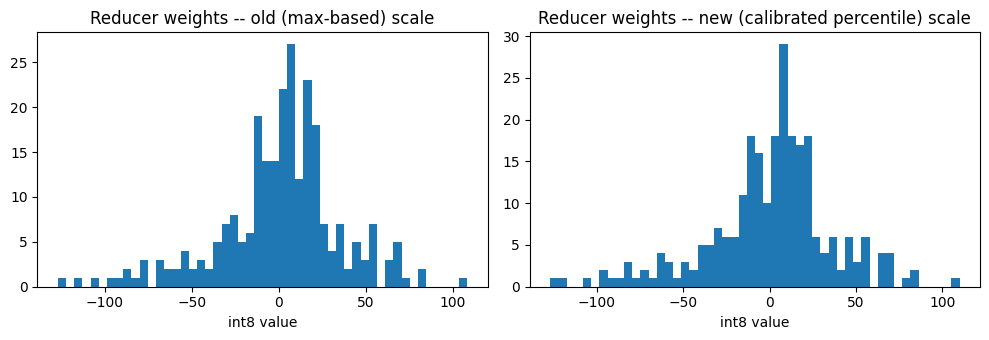

Old scheme: 115 unique int8 values used (of 255 possible)
New scheme: 110 unique int8 values used (of 255 possible)


In [ ]:
# ============================================================
# DIAGNOSTIC: weight value distribution, old scheme vs new
# (shows whether quantized values use the full int8 range or
#  cluster into a narrow band -- the original "EE-F7" symptom)
# ============================================================

def quantize_tensor_naive(t):
    """The ORIGINAL scheme, kept only for this comparison: raw max-abs scale,
       bias quantized independently."""
    max_abs = t.abs().max().item()
    if max_abs == 0:
        max_abs = 1.0
    scale = max_abs / 127.0
    q = torch.round(t / scale)
    q = torch.clamp(q, -127, 127)
    return q.to(torch.int8), scale


naive_reducer_q, _ = quantize_tensor_naive(model.reducer.data.cpu())
new_reducer_q = qmodel["reducer"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(naive_reducer_q.flatten().numpy(), bins=50)
axes[0].set_title("Reducer weights -- old (max-based) scale")
axes[0].set_xlabel("int8 value")

axes[1].hist(new_reducer_q.flatten().numpy(), bins=50)
axes[1].set_title("Reducer weights -- new (calibrated percentile) scale")
axes[1].set_xlabel("int8 value")

plt.tight_layout()
plt.show()

print(f"Old scheme: {len(torch.unique(naive_reducer_q))} unique int8 values used (of 255 possible)")
print(f"New scheme: {len(torch.unique(new_reducer_q))} unique int8 values used (of 255 possible)")

## Memory export -- address map

Your RTL's `data_mem.v` header comment lists a memory map, but a couple of its sizes don't
match the actual tensor element counts (e.g. it lists `reducer` as 64 bytes and each bias
region as "64x4(256) bytes", when the real `reducer`/`W3`/`bW3` tensors are each `16x4x4 = 256`
bytes and `fc1_bias`/`fc2_bias` are each genuinely only 64 bytes). Since nothing in the RTL
actually *enforces* those specific addresses (`data_mem.v` just does one flat
`$readmemh("stage5/data.mem", mem)` over the whole array), the comment is documentation only --
it doesn't have to match what's below, but you'll want to update that comment (or tell me your
intended addresses) so the two stay in sync.

The layout below is self-consistent with the real tensor sizes and is computed programmatically
(not hand-typed) to avoid the kind of arithmetic slip that caused problems before. **If you
already generated `.s` files against the old `0x4500` image address, you'll need to regenerate
them with the new addresses printed below.**

In [ ]:
import numpy as np

def to_u8(v):
    return int(v) & 0xFF

def split_cols_row_major(matrix, group_size=4):
    rows, cols = matrix.shape
    assert cols % group_size == 0
    n_chunks = cols // group_size
    flat = []
    for c in range(n_chunks):
        chunk = matrix[:, c*group_size:(c+1)*group_size]
        flat.extend(chunk.flatten().tolist())
    return flat

def flatten_slices_row_major(tensor3d):
    return tensor3d.reshape(-1, 4).flatten().tolist()

def flatten_bias_words(bias_1d):
    return list(bias_1d.flatten().tolist())

def write_mem_dump(byte_list, filename, mode="w", bytes_per_block=16, start_addr=0):
    with open(filename, mode) as f:
        for i in range(0, len(byte_list), bytes_per_block):
            block_addr = start_addr + i
            f.write(f"// 0x{block_addr:08X}\n")
            block = byte_list[i:i + bytes_per_block]
            for b in block:
                f.write(f"{to_u8(b):02X}\n")


# ---- build the flat byte stream, computing addresses programmatically ----

fc1_w_T = qmodel["fc1_w"].cpu().numpy().T   # [196, 64]
fc2_w_T = qmodel["fc2_w"].cpu().numpy().T   # [64, 64]
fc1_b   = qmodel["fc1_b"].cpu().numpy()
fc2_b   = qmodel["fc2_b"].cpu().numpy()
W3      = qmodel["W3"].cpu().numpy()
bW3     = qmodel["bW3"].cpu().numpy()
reducer = qmodel["reducer"].cpu().numpy()

sections = [
    ("image_placeholder", [0] * 784),   # reserved; real image written by the image-export cell below
    ("W1 (fc1 weight, 16x[196x4] chunks)", split_cols_row_major(fc1_w_T, 4)),
    ("fc1_bias (64 values)",              flatten_bias_words(fc1_b)),
    ("W2 (fc2 weight, 16x[64x4] chunks)", split_cols_row_major(fc2_w_T, 4)),
    ("fc2_bias (64 values)",              flatten_bias_words(fc2_b)),
    ("W3 (16x[4x4] slices)",              flatten_slices_row_major(W3)),
    ("bW3 (16x[4x4] slices)",             flatten_slices_row_major(bW3)),
    ("reducer (16x[4x4] slices)",         flatten_slices_row_major(reducer)),
]

addr = 0
mem_map = {}
section_addrs = []
for name, values in sections:
    start = addr
    for v in values:
        mem_map[addr] = to_u8(v)
        addr += 1
    section_addrs.append((name, start, addr - 1, len(values)))

IMAGE_START_ADDR = section_addrs[0][1]     # 0x0000, real image bytes written later
NEXT_FREE_ADDR   = addr                    # where anything after reducer can go

MEM_FILE = "nova_memory.mem"

max_addr = max(mem_map.keys())
byte_list = [mem_map.get(a, 0) for a in range(max_addr + 1)]
write_mem_dump(byte_list, MEM_FILE, mode="w", start_addr=0)

print(f"Saved {MEM_FILE} : {len(byte_list)} bytes (0x0000 - 0x{max_addr:04X})\n")
print(f"{'Section':40s} {'Start':>8s} {'End':>8s} {'#Bytes':>8s}")
print("-" * 70)
for name, s, e, n in section_addrs:
    print(f"{name:40s} 0x{s:04X}   0x{e:04X}   {n:6d}")

print(f"\nNext free address after fixed sections: 0x{NEXT_FREE_ADDR:04X}")

# ---- companion human-readable config for your assembly generator ----
with open("quant_config.txt", "w") as f:
    f.write("NOVA4 quantization config (calibrated pipeline)\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"fc1_shift = {qmodel['fc1_shift']}\n")
    f.write(f"fc2_shift = {qmodel['fc2_shift']}\n")
    f.write(f"w2_shift  = {qmodel['w2_shift']}\n\n")
    f.write(f"input_scale = {qmodel['input_scale']:.8f}\n\n")
    f.write("Memory map:\n")
    for name, s, e, n in section_addrs:
        f.write(f"  {name:40s} 0x{s:04X} - 0x{e:04X}  ({n} bytes)\n")

print("\nWrote quant_config.txt with shifts + address map for your assembly generator.")

Saved nova_memory.mem : 18320 bytes (0x0000 - 0x478F)

Section                                     Start      End   #Bytes
----------------------------------------------------------------------
image_placeholder                        0x0000   0x030F      784
W1 (fc1 weight, 16x[196x4] chunks)       0x0310   0x340F    12544
fc1_bias (64 values)                     0x3410   0x344F       64
W2 (fc2 weight, 16x[64x4] chunks)        0x3450   0x444F     4096
fc2_bias (64 values)                     0x4450   0x448F       64
W3 (16x[4x4] slices)                     0x4490   0x458F      256
bW3 (16x[4x4] slices)                    0x4590   0x468F      256
reducer (16x[4x4] slices)                0x4690   0x478F      256

Next free address after fixed sections: 0x4790

Wrote quant_config.txt with shifts + address map for your assembly generator.


## Test image -- pulled directly from the MNIST test set

No external file needed -- picks a real sample straight out of `test_dataset`.

Using test_dataset[0], true label = 7
Rewrote nova_memory.mem : 18320 bytes with image data starting at 0x00000000, ending at 0x0000030F


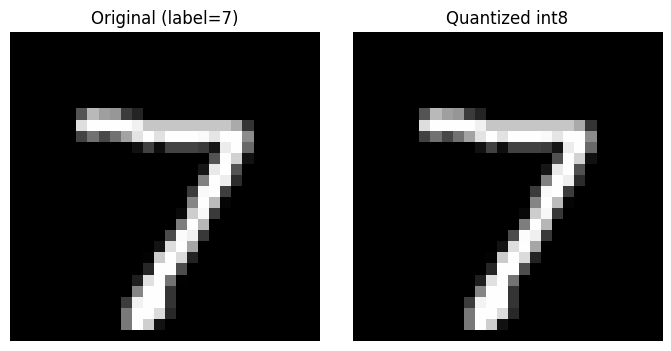

In [ ]:
# ============================================================
# TEST IMAGE -- from the MNIST test set directly (no external file)
# ============================================================

TEST_IMAGE_INDEX = None   # set an explicit index, or leave None to search by digit
TEST_IMAGE_DIGIT = 7     # used only when TEST_IMAGE_INDEX is None

if TEST_IMAGE_INDEX is None:
    TEST_IMAGE_INDEX = next(i for i in range(len(test_dataset)) if test_dataset[i][1] == TEST_IMAGE_DIGIT)

img_normalized, true_label = test_dataset[TEST_IMAGE_INDEX]   # [1,28,28], already ToTensor+Normalize'd
img_normalized = img_normalized.to(device)

# de-normalize just for display (recover the original pixel look)
img_display = img_normalized.squeeze(0).cpu().numpy() * 0.3081 + 0.1307

q = torch.round(img_normalized / qmodel["input_scale"])
img_q = torch.clamp(q, -128, 127).to(torch.int8).squeeze(0).cpu().numpy()

print(f"Using test_dataset[{TEST_IMAGE_INDEX}], true label = {true_label}")

def flatten_column_major(mat):
    return mat.T.flatten().tolist()


img_bytes = flatten_column_major(img_q)
pad = (-len(img_bytes)) % 16
if pad:
    img_bytes.extend([0] * pad)

# Update the global mem_map with the actual image bytes
for i, byte_val in enumerate(img_bytes):
    mem_map[IMAGE_START_ADDR + i] = to_u8(byte_val)

# Rewrite the entire nova_memory.mem file with the updated mem_map
max_addr = max(mem_map.keys())
byte_list = [mem_map.get(a, 0) for a in range(max_addr + 1)]
write_mem_dump(byte_list, MEM_FILE, mode="w", start_addr=0)

print(f"Rewrote {MEM_FILE} : {len(byte_list)} bytes with image data starting at "
      f"0x{IMAGE_START_ADDR:08X}, ending at 0x{IMAGE_START_ADDR + len(img_bytes) - 1:08X}")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(img_display, cmap="gray"); axes[0].set_title(f"Original (label={true_label})"); axes[0].axis("off")
axes[1].imshow(img_q, cmap="gray"); axes[1].set_title("Quantized int8"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RUN THE CALIBRATED INT8 MODEL ON THIS TEST IMAGE
# ============================================================

single_input = img_normalized.unsqueeze(0)   # [1,1,28,28]

with torch.no_grad():
    scores = int8_forward_v2(qmodel, single_input)

pred = scores.argmax(1).item()

print("Per-class scores:")
for digit, score in enumerate(scores.squeeze(0).tolist()):
    marker = "  <-- predicted" if digit == pred else ""
    print(f"  {digit}: {score:6d}{marker}")

print(f"\nPredicted digit: {pred}   (true label: {true_label})")

Per-class scores:
  0:   -501
  1:   -545
  2:    102
  3:   3106
  4:  -5928
  5:  -1582
  6:  -7443
  7:   6920  <-- predicted
  8:  -5595
  9:   1643

Predicted digit: 7   (true label: 7)


## Assembly generation -- layers 1, 2, W3, reducer (consolidated)

Folding `code_gen.py` and `reducer_gen.py` into the notebook so every address comes straight
from the memory-export cells above -- no more hand-copied literals that can drift out of sync
with the actual layout.

While consolidating, two real bugs turned up in the standalone `code_gen.py` (the W3 layer
generator):

1. **`IMG_ADDR` and `OUT_BASE` were both `0x5000`.** Every chunk's activation-input pointer
   (`R2`) was being set to *that chunk's own output address* instead of the corresponding chunk
   of layer 2's output. Since W3's `S` tensor is built from `fc2`'s output via
   `reshape(B,4,16,4).permute(0,2,1,3)`, chunk `i`'s input is exactly fc2's **output chunk `i`**
   (stored at `layer2_out_base + i*64` under the shared 64-word-per-chunk convention) -- a
   *different* address from where W3 writes its own result, not the same one.
2. **The bias-add step used the fc1/fc2 broadcast pattern** (`bias_index = 4*chunk + col`,
   the same bias column reused across all 4 rows). That pattern is only correct for `fc1`/`fc2`,
   where a `[64]`-length bias vector is broadcast across the "4 slice-rows" dimension. W3's bias
   (`b2`/`bW3` in the model) is a full `[16,4,4]` tensor added **elementwise** -- chunk `i`'s
   bias is its own **matching 4x4 slice**, not a broadcast column.
3. **Output stride mismatch**: `code_gen.py` used `OUT_STRIDE = 16` for W3's output, but
   `reducer_gen.py` assumes the layer-3 output uses a **64-word stride per chunk** (same as
   fc1/fc2). Left as-is, the reducer would have read from the wrong addresses entirely.

The generator below has two modes that capture the actual difference between these two layer
shapes, rather than reusing one bias-add pattern everywhere:
- `"broadcast_bias"` -- fc1, fc2: weight split into 4-column chunks, **fixed** activation input,
  bias broadcast across rows.
- `"elementwise_bias"` -- W3: each chunk is already a full 4x4 weight slice, activation input
  **varies per chunk** (previous layer's own chunk output), bias added elementwise per chunk.

**Assumes the `data_mem.v` patch has been applied** (general ALU port is now
single-byte granular, sign-extended on read, low-byte-only on write). Without that
patch, every `LOAD`/`STORE` in the bias-add and reducer code below would scramble
4 neighboring densely-packed int8 values together instead of isolating one element.

In [ ]:
# ============================================================
# GENERIC LAYER ASSEMBLY GENERATOR
# Covers fc1, fc2 ("broadcast_bias") and W3 ("elementwise_bias").
# ============================================================

def generate_layer_asm(layer_name, mode,
                        weight_start, k, num_chunks,
                        bias_base, out_base, out_stride,
                        act_in_base=None, act_in_stride=None,
                        a_mode="S", b_mode="S", chunk_weight_elems=None):
    """
    mode = "broadcast_bias"  (fc1, fc2):
        - weight split into `num_chunks` column-groups of 4, each chunk is [k x 4]
        - activation input is FIXED at act_in_base for every chunk
        - bias broadcast: bias_index = 4*chunk + col

    mode = "elementwise_bias"  (W3):
        - each chunk IS a full weight slice already (chunk_weight_elems = k*4, e.g. 16 for 4x4)
        - activation input VARIES per chunk: act_in_base + chunk*act_in_stride
        - bias added elementwise: bias_index = chunk*16 + 4*r + c  (matches [16,4,4] layout)
    """
    assert mode in ("broadcast_bias", "elementwise_bias")
    if chunk_weight_elems is None:
        chunk_weight_elems = k * 4   # default: k rows x 4 cols per chunk

    lines = []
    def emit(s=""):
        lines.append(s)

    emit("# =============================================================")
    emit(f"# {layer_name}")
    emit(f"#   {num_chunks} matmuls, K={k}, mode={mode}")
    emit("# =============================================================")
    emit()

    if mode == "broadcast_bias":
        emit(f"LOADI R2, 0x{act_in_base:08X}        ; activation input (fixed for all chunks)")
        emit()

    emit("# -------------------------------------------------------------")
    emit("# Step 1: matmuls")
    emit("# -------------------------------------------------------------")
    for i in range(num_chunks):
        w_addr = weight_start + i * chunk_weight_elems
        out_addr = out_base + i * out_stride
        emit()
        emit(f"# --- chunk {i} ---")
        emit(f"LOADI R1, 0x{w_addr:08X}        ; weight chunk {i}")
        emit(f"LOADI R3, 0x{out_addr:08X}        ; output block {i}")
        if mode == "elementwise_bias":
            in_addr = act_in_base + i * act_in_stride
            emit(f"LOADI R2, 0x{in_addr:08X}        ; activation input chunk {i} (from previous layer's own chunk {i})")
        emit(f"MATMUL R3, R2, R1, {a_mode}, {b_mode}, {k}")
        emit("NOP")
        emit("NOP")

    emit()
    emit("# =============================================================")
    emit("# Step 2: bias add")
    emit("# =============================================================")
    emit()
    if mode == "broadcast_bias":
        emit(f"LOADI R9, 0x{bias_base:08X}        ; bias base ({num_chunks*4} values)")
        emit()
        for i in range(num_chunks):
            out_addr = out_base + i * out_stride
            emit(f"# --- bias add: chunk {i} (output cols {4*i}-{4*i+3}) ---")
            emit(f"LOADI R8, 0x{out_addr:08X}")
            for r in range(4):
                for c in range(4):
                    off = 4 * r + c
                    bias_off = 4 * i + c   # BROADCAST: same bias col for every row
                    emit(f"LOAD  R10, R8, {off}")
                    emit(f"LOAD  R11, R9, {bias_off}")
                    emit("ADD   R10, R10, R11")
                    emit(f"STORE R10, R8, {off}")
            emit()
    else:  # elementwise_bias
        for i in range(num_chunks):
            out_addr = out_base + i * out_stride
            bias_chunk_addr = bias_base + i * 16
            emit(f"# --- bias add: chunk {i} (elementwise, own 4x4 bias slice) ---")
            emit(f"LOADI R8, 0x{out_addr:08X}")
            emit(f"LOADI R9, 0x{bias_chunk_addr:08X}")
            for r in range(4):
                for c in range(4):
                    off = 4 * r + c
                    emit(f"LOAD  R10, R8, {off}")
                    emit(f"LOAD  R11, R9, {off}   ; bias[{i}][{r}][{c}], same offset within its own slice")
                    emit("ADD   R10, R10, R11")
                    emit(f"STORE R10, R8, {off}")
            emit()

    return "\n".join(lines)


# ------------------------------------------------------------
# Scratch addresses for intermediate activations (after the fixed
# weight/bias/reducer sections exported above)
# ------------------------------------------------------------
LAYER1_OUT_BASE = NEXT_FREE_ADDR
LAYER2_OUT_BASE = LAYER1_OUT_BASE + 16 * 64   # 1024 bytes per stage
LAYER3_OUT_BASE = LAYER2_OUT_BASE + 16 * 64

print("Scratch activation addresses (16 chunks x 64-word stride each):")
print(f"  layer1 (fc1) output : 0x{LAYER1_OUT_BASE:08X}")
print(f"  layer2 (fc2) output : 0x{LAYER2_OUT_BASE:08X}")
print(f"  layer3 (W3)  output : 0x{LAYER3_OUT_BASE:08X}")

Scratch activation addresses (16 chunks x 64-word stride each):
  layer1 (fc1) output : 0x00004790
  layer2 (fc2) output : 0x00004B90
  layer3 (W3)  output : 0x00004F90


In [ ]:
# ============================================================
# GENERATE LAYER 1/2/3 ASSEMBLY (as strings -- combined into a
# single full.asm two cells down; no separate per-layer files)
#
# Modes/K per layer (as specified):
#   layer1 (fc1): a_mode=S, b_mode=S, K=196
#   layer2 (fc2): a_mode=P, b_mode=S, K=64
#   layer3 (W3) : a_mode=P, b_mode=S, K=4
# ============================================================

(_, IMAGE_ADDR_, _, _), \
(_, W1_ADDR, _, _), \
(_, FC1_BIAS_ADDR, _, _), \
(_, W2_ADDR, _, _), \
(_, FC2_BIAS_ADDR, _, _), \
(_, W3_ADDR, _, _), \
(_, BW3_ADDR, _, _), \
(_, REDUCER_ADDR, _, _) = section_addrs

print("Addresses used for codegen:")
for label, addr in [("image", IMAGE_ADDR_), ("W1", W1_ADDR), ("fc1_bias", FC1_BIAS_ADDR),
                    ("W2", W2_ADDR), ("fc2_bias", FC2_BIAS_ADDR),
                    ("W3", W3_ADDR), ("bW3", BW3_ADDR), ("reducer", REDUCER_ADDR)]:
    print(f"  {label:10s} 0x{addr:08X}")

# ---- Layer 1 (fc1) ----
asm1 = generate_layer_asm(
    "LAYER 1 (fc1): 4x196 @ 196x64 -> 4x64",
    mode="broadcast_bias",
    weight_start=W1_ADDR, k=196, num_chunks=16,
    chunk_weight_elems=196 * 4,
    bias_base=FC1_BIAS_ADDR,
    out_base=LAYER1_OUT_BASE, out_stride=16,
    act_in_base=IMAGE_ADDR_,
    a_mode="S", b_mode="S"
)

# ---- Layer 2 (fc2) ----
asm2 = generate_layer_asm(
    "LAYER 2 (fc2): 4x64 @ 64x64 -> 4x64",
    mode="broadcast_bias",
    weight_start=W2_ADDR, k=64, num_chunks=16,
    chunk_weight_elems=64 * 4,
    bias_base=FC2_BIAS_ADDR,
    out_base=LAYER2_OUT_BASE, out_stride=64,
    act_in_base=LAYER1_OUT_BASE,
    a_mode="P", b_mode="S"
)

# ---- Layer 3 (W3) -- per-chunk varying input address ----
asm3 = generate_layer_asm(
    "LAYER 3 (W3): per-slice 4x4 @ 4x4 -> 4x4, elementwise bias",
    mode="elementwise_bias",
    weight_start=W3_ADDR, k=4, num_chunks=16,
    chunk_weight_elems=16,
    bias_base=BW3_ADDR,
    out_base=LAYER3_OUT_BASE, out_stride=64,
    act_in_base=LAYER2_OUT_BASE, act_in_stride=64,
    a_mode="P", b_mode="S"
)

print(f"\nasm1: {len(asm1.splitlines())} lines")
print(f"asm2: {len(asm2.splitlines())} lines")
print(f"asm3: {len(asm3.splitlines())} lines")

Addresses used for codegen:
  image      0x00000000
  W1         0x00000310
  fc1_bias   0x00003410
  W2         0x00003450
  fc2_bias   0x00004450
  W3         0x00004490
  bW3        0x00004590
  reducer    0x00004690

asm1: 1200 lines
asm2: 1200 lines
asm3: 1228 lines


In [ ]:
# ============================================================
# REDUCER LAYER + FINAL ASSEMBLY -- writes ONE combined full.asm
# (single HALT at the very end; no separate per-layer files)
# ============================================================

def decompose_constant(k):
    if k == 0:
        return [], False
    neg = k < 0
    mag = abs(k)
    shifts = []
    bit = 0
    while mag:
        if mag & 1:
            shifts.append(bit)
        mag >>= 1
        bit += 1
    return shifts, neg


def generate_reducer_asm(reducer_q, r_base, r_stride=64, result_regs=None):
    if result_regs is None:
        result_regs = [f"R{i}" for i in range(1, 11)]
    assert len(result_regs) == 10

    ADDR_REG, ELEM_REG, PROD_REG, TEMP_REG = "R11", "R12", "R13", "R14"
    lines = []
    def emit(s=""):
        lines.append(s)

    emit("# ============================================================")
    emit("# REDUCER LAYER")
    emit(f"#   Frobenius inner product of the first 10 (of 16) 4x4 'R'")
    emit(f"#   matrices (layer-3/W3 output, 0x{r_base:08X}, {r_stride}-word stride)")
    emit("#   against the reducer weights (compile-time constants).")
    emit("# ============================================================")
    emit()

    for m in range(10):
        sum_reg = result_regs[m]
        emit(f"# ---------------- matrix {m} ----------------")
        emit(f"LOADI {sum_reg}, 0")

        for r in range(4):
            for c in range(4):
                k = int(reducer_q[m][r][c])
                offset = 4 * r + c
                addr = r_base + m * r_stride + offset
                if k == 0:
                    continue
                emit(f"LOADI {ADDR_REG}, 0x{addr:08X}")
                emit(f"LOAD  {ELEM_REG}, {ADDR_REG}, 0")
                shifts, neg = decompose_constant(k)
                first = True
                for s in shifts:
                    if first:
                        emit(f"SHL   {PROD_REG}, {ELEM_REG}, {s}")
                        first = False
                    else:
                        emit(f"SHL   {TEMP_REG}, {ELEM_REG}, {s}")
                        emit(f"ADD   {PROD_REG}, {PROD_REG}, {TEMP_REG}")
                op = "SUB" if neg else "ADD"
                emit(f"{op}   {sum_reg}, {sum_reg}, {PROD_REG}")
        emit()

    emit("HALT")
    return "\n".join(lines)


reducer_np = qmodel["reducer"].cpu().numpy()
asm_reducer = generate_reducer_asm(reducer_np, r_base=LAYER3_OUT_BASE, r_stride=64)

full_asm = "\n\n".join([asm1, asm2, asm3, asm_reducer])

with open("full.asm", "w") as f:
    f.write(full_asm)

print(f"Wrote full.asm : {len(full_asm.splitlines())} total lines")
print(f"  layer1 (fc1): {len(asm1.splitlines())} lines")
print(f"  layer2 (fc2): {len(asm2.splitlines())} lines")
print(f"  layer3 (W3) : {len(asm3.splitlines())} lines")
print(f"  reducer     : {len(asm_reducer.splitlines())} lines")
print(f"\nnova_memory.mem already contains weights/biases/reducer + the test image "
      f"(written by the memory-export and test-image cells above).")

Wrote full.asm : 4914 total lines
  layer1 (fc1): 1200 lines
  layer2 (fc2): 1200 lines
  layer3 (W3) : 1228 lines
  reducer     : 1280 lines

nova_memory.mem already contains weights/biases/reducer + the test image (written by the memory-export and test-image cells above).


In [ ]:
# ============================================================
# FALLBACK: load reducer weights from a saved nova_memory.mem file
# (use this instead of qmodel["reducer"] if the kernel/session is
#  ever lost again and you only have the exported .mem file)
# ============================================================

def load_mem_file(path):
    mem = {}
    current_addr = None
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("//"):
                current_addr = int(line[2:].strip(), 16)
                continue
            val = int(line, 16)
            if val >= 128:
                val -= 256
            mem[current_addr] = val
            current_addr += 1
    return mem


def read_reducer_from_mem(mem, reducer_base):
    reducer = [[[0]*4 for _ in range(4)] for _ in range(16)]
    for m in range(16):
        for r in range(4):
            for c in range(4):
                reducer[m][r][c] = mem[reducer_base + m*16 + 4*r + c]
    return reducer

# Example usage (uncomment if needed):
# mem = load_mem_file("nova_memory.mem")
# reducer_from_file = read_reducer_from_mem(mem, reducer_base=REDUCER_ADDR)
# asm_reducer = generate_reducer_asm(reducer_from_file, r_base=LAYER3_OUT_BASE, r_stride=64)

## Stagewise hardware verification

Reads the memory dump straight from the accelerator (`nova_memory.mem` -- whatever your
simulator wrote out, e.g. via `data_mem.v`'s `$writememh`), reconstructs each layer's weights
and activations from their known address layout, and compares them element-by-element against
the golden (calibrated int8) values this notebook already computed. This is what would have
caught the `LOADI` upper-half corruption bug immediately: weights would show up correct
(since they're never touched by that bug) while every activation stage downstream of the first
corrupted `LOADI` would show huge deviation.

**Loader handles both memory-dump conventions:**
- one byte (2 hex digits) per line -- addresses auto-increment by 1
- one 32-bit word (8 hex digits) per line -- split into 4 bytes assigned **little-endian**
  (lowest address = LSB), matching `data_mem.v`'s actual read logic:
  `{mem[addr+3], mem[addr+2], mem[addr+1], mem[addr]}`

In [ ]:
# ============================================================
# FLEXIBLE MEMORY LOADER
# Accepts either byte-per-line or word-per-line ($writememh-style)
# dumps, with correct little-endian byte splitting for word entries.
# ============================================================

def load_mem_file_flexible(path):
    """Returns dict: address -> unsigned byte value (0-255)."""
    mem = {}
    current_addr = 0
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("//"):
                current_addr = int(line[2:].strip(), 16)
                continue
            if line.startswith("@"):          # Verilog $readmemh-style address directive
                current_addr = int(line[1:].strip(), 16)
                continue

            hex_str = line.split()[0]
            val = int(hex_str, 16)

            if len(hex_str) <= 2:
                # single byte
                mem[current_addr] = val & 0xFF
                current_addr += 1
            else:
                # multi-byte word -- split LITTLE-ENDIAN (LSB at lowest address),
                # matching data_mem.v: {mem[addr+3],mem[addr+2],mem[addr+1],mem[addr]}
                nbytes = (len(hex_str) + 1) // 2
                for i in range(nbytes):
                    mem[current_addr + i] = (val >> (8 * i)) & 0xFF
                current_addr += nbytes
    return mem


def to_signed_i8(v):
    return v - 256 if v >= 128 else v


def read_bytes_signed(mem, base, count):
    return np.array([to_signed_i8(mem.get(base + i, 0)) for i in range(count)], dtype=np.int8)

In [ ]:
# ============================================================
# STAGEWISE VERIFICATION -- base addresses + shifts (edit these to
# match whatever's actually in your memory dump)
# ============================================================

HW_MEM_FILE = "output.mem"     # <-- the memory dump the accelerator writes out after running full.asm

# --- weight / bias base addresses ---
ADDR_IMAGE    = IMAGE_ADDR_
ADDR_W1       = W1_ADDR
ADDR_FC1_BIAS = FC1_BIAS_ADDR
ADDR_W2       = W2_ADDR
ADDR_FC2_BIAS = FC2_BIAS_ADDR
ADDR_W3       = W3_ADDR
ADDR_BW3      = BW3_ADDR
ADDR_REDUCER  = REDUCER_ADDR

# --- activation (intermediate output) base addresses ---
ADDR_ACT1 = LAYER1_OUT_BASE     # fc1 output, post relu+shift
ADDR_ACT2 = LAYER2_OUT_BASE     # fc2 output, post relu+shift
ADDR_ACT3 = LAYER3_OUT_BASE     # W3 output, post relu+shift

# --- shift amount per stage (right-shift applied during requantization) ---
SHIFT_FC1 = qmodel["fc1_shift"]
SHIFT_FC2 = qmodel["fc2_shift"]
SHIFT_W3  = qmodel["w2_shift"]

OUT_STRIDE = 64   # words reserved per chunk (only first 16 of each block are real data)


def extract_broadcast_weight(mem, base, rows, num_chunks=16, group=4):
    """Reconstruct [rows, num_chunks*group] from column-chunks (fc1/fc2 weight layout)."""
    cols = num_chunks * group
    out = np.zeros((rows, cols), dtype=np.int8)
    chunk_elems = rows * group
    for i in range(num_chunks):
        flat = read_bytes_signed(mem, base + i * chunk_elems, chunk_elems)
        out[:, i*group:(i+1)*group] = flat.reshape(rows, group)
    return out

def extract_bias(mem, base, count):
    return read_bytes_signed(mem, base, count)

def extract_w3_weight(mem, base):
    out = np.zeros((16, 4, 4), dtype=np.int8)
    for i in range(16):
        out[i] = read_bytes_signed(mem, base + i*16, 16).reshape(4, 4)
    return out

def extract_broadcast_activation(mem, base, num_chunks=16, stride=OUT_STRIDE):
    """Reconstruct logical [4,64] activation from 16 chunks of 4x4, `stride`-word spaced."""
    out = np.zeros((4, 64), dtype=np.int8)
    for i in range(num_chunks):
        chunk = read_bytes_signed(mem, base + i*stride, 16).reshape(4, 4)
        out[:, i*4:(i+1)*4] = chunk
    return out

def extract_w3_activation(mem, base, num_chunks=16, stride=OUT_STRIDE):
    """Reconstruct logical [16,4,4] activation (W3/R output) from 16 chunks."""
    out = np.zeros((16, 4, 4), dtype=np.int8)
    for i in range(num_chunks):
        out[i] = read_bytes_signed(mem, base + i*stride, 16).reshape(4, 4)
    return out

In [ ]:
# ============================================================
# GOLDEN REFERENCE -- same hardware-order pipeline, returns every
# intermediate stage instead of just final scores
# ============================================================

def int8_forward_debug(model_q, image, shift_fc1, shift_fc2, shift_w3):
    B = image.shape[0]
    x = image.flatten(start_dim=1)
    x = torch.round(x / model_q["input_scale"])
    x = torch.clamp(x, -128, 127).to(torch.int8)
    x_in = x.reshape(B, 4, 196).to(torch.int32)

    fc1_w = model_q["fc1_w"].to(torch.int32)
    acc1 = torch.matmul(x_in, fc1_w.t())
    acc1 = torch.relu(acc1)
    stage1 = requantize(acc1, shift_fc1)
    act1 = add_bias_truncating(stage1, model_q["fc1_b"])

    fc2_w = model_q["fc2_w"].to(torch.int32)
    acc2 = torch.matmul(act1.to(torch.int32), fc2_w.t())
    acc2 = torch.relu(acc2)
    stage2 = requantize(acc2, shift_fc2)
    act2 = add_bias_truncating(stage2, model_q["fc2_b"])

    xr = act2.reshape(B, 4, 16, 4).permute(0, 2, 1, 3)
    S = xr.reshape(B * 16, 4, 4).to(torch.int32)
    W3 = model_q["W3"].to(torch.int32).unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
    acc3 = torch.bmm(S, W3)
    acc3 = torch.relu(acc3)
    stage3 = requantize(acc3, shift_w3)
    bW3 = model_q["bW3"].to(torch.int32).unsqueeze(0).expand(B, -1, -1, -1).reshape(B * 16, 4, 4)
    act3 = add_bias_truncating(stage3, bW3).reshape(B, 16, 4, 4)

    return {
        "input": x_in.squeeze(0).numpy(),
        "act1":  act1.squeeze(0).numpy(),
        "act2":  act2.squeeze(0).numpy(),
        "act3":  act3.squeeze(0).numpy(),
    }


golden = int8_forward_debug(qmodel, single_input, SHIFT_FC1, SHIFT_FC2, SHIFT_W3)
print("Golden reference computed (matches hardware order: relu+shift on matmul-only, "
      "then bias added afterward with wraparound truncation).")

Golden reference computed (matches hardware order: relu+shift on matmul-only, then bias added afterward with wraparound truncation).


In [ ]:
# ============================================================
# COMPARE HARDWARE MEMORY DUMP AGAINST GOLDEN, STAGE BY STAGE
# ============================================================

def compute_stats(golden_arr, actual_arr):
    g = golden_arr.astype(np.int32).flatten()
    a = actual_arr.astype(np.int32).flatten()
    diff = a - g
    stats = {
        "max_abs_diff":    int(np.abs(diff).max()),
        "mean_abs_diff":   float(np.abs(diff).mean()),
        "pct_exact_match": float((diff == 0).mean() * 100),
    }
    if g.std() > 0 and a.std() > 0:
        stats["correlation"] = float(np.corrcoef(g, a)[0, 1])
    else:
        stats["correlation"] = float("nan")
    return stats


def print_stage(name, golden_arr, actual_arr):
    s = compute_stats(golden_arr, actual_arr)
    flag = "  <-- MISMATCH" if s["max_abs_diff"] != 0 else ""
    print(f"{name:22s} max|diff|={s['max_abs_diff']:5d}  "
          f"mean|diff|={s['mean_abs_diff']:7.3f}  "
          f"exact={s['pct_exact_match']:6.2f}%  "
          f"corr={s['correlation']:.4f}{flag}")


hw_mem = load_mem_file_flexible(HW_MEM_FILE)

print("=" * 90)
print("WEIGHTS / BIASES  (should always match exactly -- never touched by activation bugs)")
print("=" * 90)
print_stage("W1 (fc1 weight)",   qmodel["fc1_w"].numpy().T, extract_broadcast_weight(hw_mem, ADDR_W1, 196))
print_stage("fc1_bias",          qmodel["fc1_b"].numpy(),    extract_bias(hw_mem, ADDR_FC1_BIAS, 64))
print_stage("W2 (fc2 weight)",   qmodel["fc2_w"].numpy().T, extract_broadcast_weight(hw_mem, ADDR_W2, 64))
print_stage("fc2_bias",          qmodel["fc2_b"].numpy(),    extract_bias(hw_mem, ADDR_FC2_BIAS, 64))
print_stage("W3",                qmodel["W3"].numpy(),       extract_w3_weight(hw_mem, ADDR_W3))
print_stage("bW3",               qmodel["bW3"].numpy(),      extract_w3_weight(hw_mem, ADDR_BW3))
print_stage("reducer",           qmodel["reducer"].numpy(),  extract_w3_weight(hw_mem, ADDR_REDUCER))

print()
print("=" * 90)
print("ACTIVATIONS  (deviation here means something upstream corrupted this stage)")
print("=" * 90)
hw_act1 = extract_broadcast_activation(hw_mem, ADDR_ACT1)
hw_act2 = extract_broadcast_activation(hw_mem, ADDR_ACT2)
hw_act3 = extract_w3_activation(hw_mem, ADDR_ACT3)

print_stage("act1 (post fc1, shift={})".format(SHIFT_FC1), golden["act1"], hw_act1)
print_stage("act2 (post fc2, shift={})".format(SHIFT_FC2), golden["act2"], hw_act2)
print_stage("act3 (post W3,  shift={})".format(SHIFT_W3),  golden["act3"], hw_act3)

print()
print("If weights match exactly but act1 already shows large max|diff| / low correlation,")
print("the bug is in the fc1 stage (or an address feeding it) -- not further downstream.")
print("If act1 matches but act2 doesn't, the bug is isolated to the fc2 stage, etc.")

WEIGHTS / BIASES  (should always match exactly -- never touched by activation bugs)
W1 (fc1 weight)        max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
fc1_bias               max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
W2 (fc2 weight)        max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
fc2_bias               max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
W3                     max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
bW3                    max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000
reducer                max|diff|=    0  mean|diff|=  0.000  exact=100.00%  corr=1.0000

ACTIVATIONS  (deviation here means something upstream corrupted this stage)
act1 (post fc1, shift=10) max|diff|=  122  mean|diff|= 23.469  exact= 11.33%  corr=0.0012  <-- MISMATCH
act2 (post fc2, shift=9) max|diff|=   97  mean|diff|= 12.020  exact= 27.34%  corr=0.6831  <-- MISMATCH
act3 (post W3,  shift=7